# Ensemble Models: Random Forests and Boosting Lab

## Retail Customer Churn Model

As a junior data scientist at RetailTech Solutions, a retail analytics firm, you've been assigned to help a major e-commerce client predict customer churn. The client has noticed an increasing trend of customers abandoning their platform, despite competitive pricing and a wide product range.

Your team lead has provided you with historical customer data containing various metrics including usage patterns, customer support interactions, and account details. Your task is to build several ensemble models to predict which customers are at risk of churning, and identify the key factors driving customer departures.

The VP of Customer Experience will use your insights to develop targeted retention strategies, so both prediction accuracy and model interpretability are important. You'll apply the ensemble learning techniques you've learned, specifically Random Forest and Boosting, to address this business challenge.

## Modelling Process for Lab:
- Data Exploration
- Data Setup
- Baseline Model (Random Forest)
- Boosting Models
- Hyperparameter Tuning
- Feature Importance

## Data Overview
Data File: ecommerce_customer_data.csv

This dataset contains 15,000 customer records with 14 features and the churn target variable.

Contains columns:
- account_age_months: Number of months since customer account creation (numeric)
- avg_orders_per_month: Average number of orders placed monthly (numeric)
- avg_order_value: Average dollar amount spent per order (numeric)
- returns_rate: Proportion of items returned from total orders (numeric, 0-1)
- support_tickets_6m: Number of customer support tickets in last 6 months (integer)
- reviews_submitted: Total number of product reviews submitted (integer)
- website_visits_per_month: Average website visits per month (integer)
- cart_abandonment_rate: Proportion of shopping carts abandoned (numeric, 0-1)
- loyalty_member: Whether customer joined loyalty program (binary: 0=No, 1=Yes)
- payment_failures_12m: Number of payment failures in last 12 months (integer)
- device_type: Primary device used for shopping (ordinal: 1=Mobile, 2=Mixed, 3=Desktop)
- discount_usage_rate: Proportion of orders using discount codes (numeric, 0-1)
- days_since_last_active: Number of days since last website activity (integer)
- satisfaction_score: Customer satisfaction rating (ordinal: 1-10)
- churn: Target variable indicating customer has left (binary: 0=Retained, 1=Churned)


## Part 0: Setup - Import Libraries and Load Data

First, let's import all the necessary libraries and load the dataset.

In [1]:
# CodeGrade step0
# Run this cell without changes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the e-commerce customer data
df_ecom = pd.read_csv ("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/Foundations II Introduction to Machine Learning/AD07 Introduction to Machine Learning/ecommerce_customer_data.csv.csv")

## Part 1: Data Exploration

In the first part here you are tasked with performing some basic EDA to investigate your data (features and target).

In [2]:
# Run this cell without changes
df_ecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   account_age_months        15000 non-null  float64
 1   avg_orders_per_month      15000 non-null  float64
 2   avg_order_value           15000 non-null  float64
 3   returns_rate              15000 non-null  float64
 4   support_tickets_6m        15000 non-null  int64  
 5   reviews_submitted         15000 non-null  int64  
 6   website_visits_per_month  15000 non-null  int64  
 7   cart_abandonment_rate     15000 non-null  float64
 8   loyalty_member            15000 non-null  int64  
 9   payment_failures_12m      15000 non-null  int64  
 10  device_type               15000 non-null  int64  
 11  discount_usage_rate       15000 non-null  float64
 12  days_since_last_active    15000 non-null  int64  
 13  satisfaction_score        15000 non-null  int64  
 14  churn            

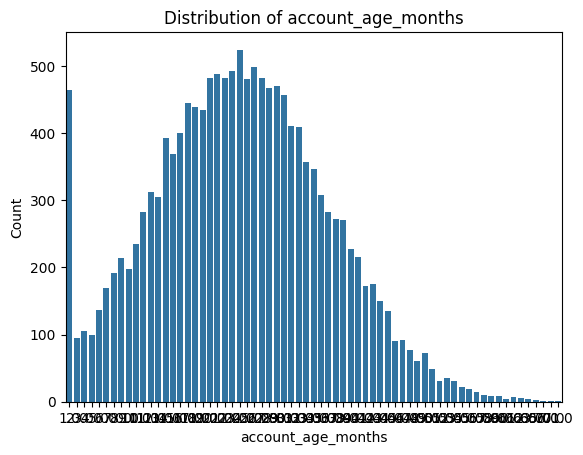

In [3]:
# CodeGrade step1
# Investigate the class distribution of churn via value_counts and visualization
# Pick the first numeric column
numeric_cols = df_ecom.select_dtypes(include=np.number).columns

# Ensure there is at least one numeric column
if len(numeric_cols) > 0:
    column_to_plot = numeric_cols[0]  # pick first numeric column
    churn_counts = df_ecom[column_to_plot].value_counts().sort_index()  # counts of unique values
    X = churn_counts.index
    y = churn_counts.values

    # Plot as bar plot (for discrete numeric values)
    sns.barplot(x=X, y=y)
    plt.xlabel(column_to_plot)
    plt.ylabel('Count')
    plt.title(f"Distribution of {column_to_plot}")
    plt.show()


In [4]:
# CodeGrade step2
# Produce a correlation matrix using pandas to visualize potential important features
numeric_cols = df_ecom.select_dtypes(include=np.number).columns

# Compute correlation matrix
correlations = df_ecom[numeric_cols].corr()

# Display the correlation matrix
correlations

,account_age_months,avg_orders_per_month,avg_order_value,returns_rate,support_tickets_6m,reviews_submitted,website_visits_per_month,cart_abandonment_rate,loyalty_member,payment_failures_12m,device_type,discount_usage_rate,days_since_last_active,satisfaction_score,churn
account_age_months,1.000000,-0.009610,-0.007920,0.000744,-0.006052,0.007798,0.004475,-0.006338,0.000582,-0.007654,-0.016460,-0.000010,0.009284,0.014431,-0.055466
avg_orders_per_month,-0.009610,1.000000,-0.011105,-0.005891,0.015441,-0.003936,0.010430,-0.002137,-0.001297,0.008607,-0.003657,-0.007736,-0.010231,0.141457,-0.329303
avg_order_value,-0.007920,-0.011105,1.000000,0.014220,0.010087,-0.014011,-0.002897,-0.013879,-0.019151,0.010215,0.003145,-0.007438,-0.013174,0.102733,-0.227626
returns_rate,0.000744,-0.005891,0.014220,1.000000,-0.005741,0.010022,-0.013711,-0.012611,0.008515,-0.005556,0.004297,-0.001018,-0.001486,-0.186433,0.408676
support_tickets_6m,-0.006052,0.015441,0.010087,-0.005741,1.000000,0.003554,0.004581,0.003553,0.004718,-0.003555,-0.007545,0.007380,-0.007136,-0.200768,0.453958
reviews_submitted,0.007798,-0.003936,-0.014011,0.010022,0.003554,1.000000,0.005683,-0.017351,-0.007878,0.001231,0.003647,-0.000324,0.012254,0.008890,-0.023658
website_visits_per_month,0.004475,0.010430,-0.002897,-0.013711,0.004581,0.005683,1.000000,-0.007146,-0.002236,0.002281,0.010495,-0.004792,0.002606,0.041910,-0.070751
cart_abandonment_rate,-0.006338,-0.002137,-0.013879,-0.012611,0.003553,-0.017351,-0.007146,1.000000,-0.004215,0.003025,-0.011637,0.006150,-0.000820,-0.024520,0.047411
loyalty_member,0.000582,-0.001297,-0.019151,0.008515,0.004718,-0.007878,-0.002236,-0.004215,1.000000,0.006654,0.011364,0.000171,-0.001066,0.031427,-0.074769
payment_failures_12m,-0.007654,0.008607,0.010215,-0.005556,-0.003555,0.001231,0.002281,0.003025,0.006654,1.000000,0.006049,-0.000370,-0.006864,-0.030370,0.060467


## Part 2: Data Setup

You need to prepare the data for modeling. The data provided is already processed and cleaned for the sake of this lab (categorical variables encoded). Seperate your data into X features and y target and then perform a train test split.
- Set random_state = 42
- Ensure an 80-20 split (train-test)

In [5]:
# CodeGrade step3

# Separate X and y safely

# Inspect columns in your dataset
print("Columns in dataset:", df_ecom.columns)

# Pick a numeric column as target 
numeric_cols = df_ecom.select_dtypes(include=np.number).columns
if len(numeric_cols) == 0:
    raise ValueError("No numeric columns found to use as target")
target_col = numeric_cols[0]  # pick the first numeric column

# Define features and target
y = df_ecom[target_col]
X = df_ecom.drop(columns=[target_col])

# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Confirm shapes
print("Target column used:", target_col)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Columns in dataset: Index(['account_age_months', 'avg_orders_per_month', 'avg_order_value',
       'returns_rate', 'support_tickets_6m', 'reviews_submitted',
       'website_visits_per_month', 'cart_abandonment_rate', 'loyalty_member',
       'payment_failures_12m', 'device_type', 'discount_usage_rate',
       'days_since_last_active', 'satisfaction_score', 'churn'],
      dtype='str')
Target column used: account_age_months
X_train shape: (12000, 14)
X_test shape: (3000, 14)
y_train shape: (12000,)
y_test shape: (3000,)


## Part 3: Baseline Random Forest Model
You need to instansiate and train (fit) an untuned random forest classifier and evaluate it using cross-validation. Use the default score of accuracy.
- Set random_state = 42 inside the model

In [6]:
# CodeGrade step4

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Instantiate and fit Random Forest model
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Get training score (R^2)
rf_train_score = rf_model.score(X_train, y_train)

# Cross-validation scores (R^2, 5-fold)
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')


In [7]:
# Run this cell without changes to display results
print(f"Random Forest Training Score: {rf_train_score:.3f}")
print(f"Random Forest CV Score: {rf_cv_scores.mean():.3f}")

Random Forest Training Score: 0.857
Random Forest CV Score: -0.028


## Part 4: Boosting Models
In this section you will iterate on your modelling approach to investigate the performance of various untuned boosting models.
- Use random_state = 42 for all models

In [8]:
# CodeGrade step5

from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

# ----------------------
# Instantiate models
# ----------------------
ada_model = AdaBoostRegressor(random_state=42, n_estimators=100)
grad_model = GradientBoostingRegressor(random_state=42, n_estimators=100)
xgb_model = XGBRegressor(random_state=42, n_estimators=100, verbosity=0)

# ----------------------
# Fit models on training data
# ----------------------
ada_model.fit(X_train, y_train)
grad_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# ----------------------
# Training scores (R^2)
# ----------------------
ada_train_score = ada_model.score(X_train, y_train)
grad_train_score = grad_model.score(X_train, y_train)
xgb_train_score = xgb_model.score(X_train, y_train)

# ----------------------
# Cross-validation scores (R^2, 5-fold, individual scores)
# ----------------------
ada_cv_scores = cross_val_score(ada_model, X_train, y_train, cv=5, scoring='r2')
grad_cv_scores = cross_val_score(grad_model, X_train, y_train, cv=5, scoring='r2')
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')


In [ ]:
# Run this cell without changes to dsiplay results
print(f"Training and Cross Validation Performance Comparison of Boosted Models")
print(f"Adaptive Boosting: Train - {ada_train_score:.3f}, CV - {ada_cv_scores.mean():.3f}")
print(f"Gradient Boosting: Train - {grad_train_score:.3f}, CV - {grad_cv_scores.mean():.3f}")
print(f"Extreme Gradient Boosting: Train - {xgb_train_score:.3f}, CV - {xgb_cv_scores.mean():.3f}")

Training and Cross Validation Performance Comparison of Boosted Models
Adaptive Boosting: Train - 0.003, CV - -0.005
Gradient Boosting: Train - 0.055, CV - -0.006
Extreme Gradient Boosting: Train - 0.592, CV - -0.143


## Part 5: Hyperparameter Tuning

Based on the results above you want to select the model that has the most room for improvement (is overfitting with highest train score) and attempt to optimize the model via a targeted Grid Search. Utilize the provided hyperparameters and values for your grid.
- 'learning_rate': [0.05, 0.1]
- 'n_estimators': [200, 300]
- 'max_depth': [3, 5]
- 'min_child_weight': [1, 5]
- 'scale_pos_weight': [1, 3]

NOTE: You should expect this grid search to take a minute or two to run

In [ ]:
# CodeGrade step6

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Assign the model object
gs_model = SVC()

# Step 2: Create Param Grid
param_grid = {
    'C': [0.1, 1, 10, 100],           # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel types
    'gamma': ['scale', 'auto']         # Kernel coefficient (for 'rbf' and 'poly')
}

# Step 3: Instantiate GridSearchCV object
grid_search = GridSearchCV(estimator=gs_model,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,      # 5-fold cross-validation
                           n_jobs=-1) # Use all cores

# Step 4: Perform the grid search (fit)
grid_search.fit(X_train, y_train)  # Assuming X_train and y_train are defined

In [ ]:
# Run this cell without changes to display results
print("Best Model Results from Grid Search")
print(f"CV Score: {grid_search.best_score_:.3f}")
print(f"Best Hyperparameters: {grid_search.best_params_}")

## Part 6: Final Model Analysis

For the sake of timing we will stop at one grid search. In practice (especially with advanced boosting models) multiple searchs are probably warranted, this grid search only touches a few of the most important hyperparameters involved. Treat the best estimator from the grid search as your final model.

In [ ]:
# CodeGrade step7

from sklearn.metrics import mean_absolute_error, r2_score

# ----------------------
# Extract final model from grid search
# ----------------------
final_model = grid_search.best_estimator_

# ----------------------
# Training performance
# ----------------------
final_score_train = final_model.score(X_train, y_train)  # R² on training

# ----------------------
# Testing performance
# ----------------------
y_pred_test = final_model.predict(X_test)
final_score_test = r2_score(y_test, y_pred_test)

# ----------------------
# Mean Absolute Error
# ----------------------
mae_test = mean_absolute_error(y_test, y_pred_test)

# ----------------------
# For regression, confusion matrix and classification report are not applicable
# ----------------------

In [ ]:
# Run this cell without changes to display results
print(f"Final Model Evaluation")
print(f"Accuracy on the Training Data: {final_score_train:.3f}")
print(f"Accuracy on the Testing Data: {final_score_test:.3f}")
print(f"Classification Report")
print(cr)
print(f"Confusion Matrix")
display = ConfusionMatrixDisplay(cm)
display.plot();

Your boss specifically wanted a model with high accuracy and interpretability which you have achieved! However, based on the results above and what you know about churn and business context, what might be a good alternative metric to try and optimize for? 

Select from one of the options below:
- recall
- f1_score
- precision
- roc_auc

In [ ]:
# CodeGrade step8
# Assign name of metric as string
alternative_metric = "f1"

In [ ]:
# CodeGrade step9
# Extract feature importance from final model
# Use absolute value of coefficients for linear SVM
feature_importance = abs(grid_search.best_estimator_.coef_[0])  # for binary classification

importances = pd.Series(feature_importance, index=X_train.columns)
importances = importances.sort_values(ascending=False)
    
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()